# CT3 for Linear Trend with Noise and SGD Classifier.

1. Instantiate generator
2. Instantiate agent
2. Train agents with flexible policy against generator on task
3. Freeze policy after training
3. Evaluate frozen policy on generator and counterfactual generator
4. Compare resulting action distributions

In [3]:
from tsdm.tasks import PredictionTask
from tsg.generators import LinearTrendGenerator
from tsg.modifiers import GaussianNoise
from custom_agents import SGDClassifierAgent
from custom_generators import NoiseTrajectoryWrapper
import numpy as np
import matplotlib.pyplot as plt
from ct3 import CT3Evaluator, CT3Runner
from factories import make_task_factory

Text(0.5, 1.0, 'Sample trajectory from generator with noise')

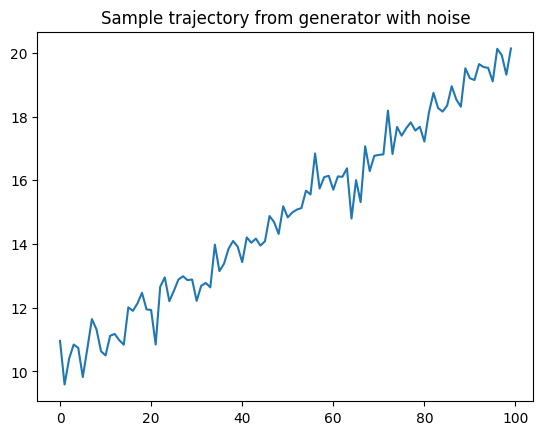

In [4]:
# instantiate generator

gen = LinearTrendGenerator(slope=0.1)
gen_noise = GaussianNoise(gen,mu=0,sigma=0.5)

# plot sample trajectories
time_horizon = 100

gen_traj = []
current_val = 0.0
for i in range(time_horizon):
    next_val = gen_noise.generate_value(current_val)
    gen_traj.append(next_val)
    current_val = next_val

plt.plot(gen_traj)
plt.title("Sample trajectory from generator with noise")

In [5]:
# instantiate agent
agent = SGDClassifierAgent(window_size=100)

In [6]:
# 2 train agent on generator in prediction task
task = PredictionTask(generator=gen_noise, agent=agent, total_movements=10000, start_value=0.0)
reward = task.play_game()
print(f"Reward on original generator: {reward}")

Reward on original generator: -3086


In [7]:
# 3 Freeze and reset buffer of agent after training

agent.freeze()
agent.soft_reset()

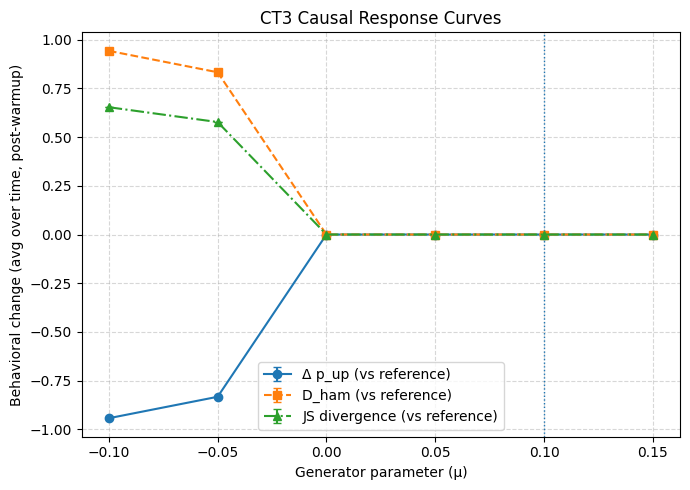

In [8]:
# 1) You already have a trained agent: `agent`
#    Ensure it's trained, then keep as the template.
#    We'll clone and freeze it per rollout.

# 2) Factories
generator_factory = lambda mu: LinearTrendGenerator(slope=mu)  # your class
noise_wrapper_cls = NoiseTrajectoryWrapper                      # must accept (base_gen, eps)

# 3) Define grid and reference
mu0 = 0.10
grid = [-0.10, -0.05, 0.0, 0.05, 0.10, 0.15]

ct3 = CT3Evaluator(
    generator_factory=generator_factory,
    noise_wrapper_cls=noise_wrapper_cls,
    agent_frozen=agent,        # trained agent (will be deep-copied & frozen)
    task_horizon=1000,
    warmup=getattr(agent, "window_size", 100),  # or set explicitly
    param_grid=grid,
    reference_param=mu0,
    n_noise_paths=20,
    seed=42,
    start_value=0.0,
)

raw = ct3.run()
fig, ax = ct3.plot_response()

In [9]:
# Example: PredictionTask
build_all = make_task_factory(
    task_cls=PredictionTask,
    gen_factory=lambda mu: LinearTrendGenerator(slope=mu),
    agent=agent,
    noise_wrapper_cls=NoiseTrajectoryWrapper,
    total_movements=1000,
    start_value=0.0,
)

bundle = build_all(
    param_grid=[-0.5, -0.25, 0.0, 0.25, 0.5],
    reference_param=0.0,
    task_horizon=1000,
    n_noise_paths=8,
    seed=123,
)

# Run them (inside your CT3 or ad-hoc)
for t in bundle["reference"]:
    t.play_game()
    print(t.log)
for mu, tasks in bundle["by_mu"].items():
    for t in tasks:
        t.play_game()


[{'t': 1, 'value_prev': 0.0, 'value': 9.010878649652149, 'bet': 0, 'received_reward': -1, 'reward_cum': -1}, {'t': 2, 'value_prev': 9.010878649652149, 'value': 9.632213348532117, 'bet': 0, 'received_reward': -1, 'reward_cum': -2}, {'t': 3, 'value_prev': 9.632213348532117, 'value': 11.28792526128925, 'bet': 0, 'received_reward': -1, 'reward_cum': -3}, {'t': 4, 'value_prev': 11.28792526128925, 'value': 10.193974419132614, 'bet': 0, 'received_reward': 1, 'reward_cum': -2}, {'t': 5, 'value_prev': 10.193974419132614, 'value': 10.920230899639858, 'bet': 0, 'received_reward': -1, 'reward_cum': -3}, {'t': 6, 'value_prev': 10.920230899639858, 'value': 10.577103791257251, 'bet': 0, 'received_reward': 1, 'reward_cum': -2}, {'t': 7, 'value_prev': 10.577103791257251, 'value': 9.36353635362902, 'bet': 0, 'received_reward': 1, 'reward_cum': -1}, {'t': 8, 'value_prev': 9.36353635362902, 'value': 10.541952220410293, 'bet': 0, 'received_reward': -1, 'reward_cum': -2}, {'t': 9, 'value_prev': 10.541952220

In [10]:
from metrics import metric_prediction

# 1) Build the factory that outputs lists of task instances
build_all = make_task_factory(
    task_cls=PredictionTask,
    gen_factory=lambda mu: LinearTrendGenerator(slope=mu),  # your base generator
    agent=agent,                                     # your frozen/trained agent
    noise_wrapper_cls=NoiseTrajectoryWrapper,                # ensures twin-noise
    total_movements=1000,
    start_value=0.0,
)

# 2) Create CT3 runner and run
ct3 = CT3Runner(
    build_all=build_all,
    param_grid=[-0.5, -0.25, 0.0, 0.25, 0.5],
    reference_param=0.0,
    task_horizon=1000,
    n_noise_paths=8,
    seed=123,
    metrics=[metric_prediction(warmup=getattr(agent, "window_size", 0))],
)

raw = ct3.run()
agg = ct3.agg    # {mu: {"D_ham": {"mean":..., "ci95":(..., ...)}, "delta_p": ..., "p_up": ...}}

# 3) (Optional) Plot your response using your existing plotter by reading ct3.agg
print(agg)


{-0.5: {'D_ham': {'mean': 1.0, 'ci95': (1.0, 1.0)}, 'delta_p': {'mean': -1.0, 'ci95': (-1.0, -1.0)}, 'p_up': {'mean': 0.0, 'ci95': (0.0, 0.0)}}, -0.25: {'D_ham': {'mean': 1.0, 'ci95': (1.0, 1.0)}, 'delta_p': {'mean': -1.0, 'ci95': (-1.0, -1.0)}, 'p_up': {'mean': 0.0, 'ci95': (0.0, 0.0)}}, 0.0: {'D_ham': {'mean': 0.0, 'ci95': (0.0, 0.0)}, 'delta_p': {'mean': 0.0, 'ci95': (0.0, 0.0)}, 'p_up': {'mean': 1.0, 'ci95': (1.0, 1.0)}}, 0.25: {'D_ham': {'mean': 0.0, 'ci95': (0.0, 0.0)}, 'delta_p': {'mean': 0.0, 'ci95': (0.0, 0.0)}, 'p_up': {'mean': 1.0, 'ci95': (1.0, 1.0)}}, 0.5: {'D_ham': {'mean': 0.0, 'ci95': (0.0, 0.0)}, 'delta_p': {'mean': 0.0, 'ci95': (0.0, 0.0)}, 'p_up': {'mean': 1.0, 'ci95': (1.0, 1.0)}}}
